# P12 — Optimizers & the Training Loop  *(teaching the mind to sprint downhill)*

> **The story so far.** In P11 the mind woke up: backprop showed it which way is downhill, and it
> took its first wobbling steps toward learning. But it walks like a toddler — tiny, hesitant,
> zig-zagging across the slope and barely making progress along it. A mind that learns this slowly
> would need a thousand lifetimes to read the internet. This chapter is its sprinting lesson. Same
> hill, same gradients from backprop — but now we teach it *how to step*: build momentum like a ball
> rolling downhill, sense which directions deserve big strides and which deserve caution, and combine
> both into **Adam**, the stride that trains nearly every modern model, GPT included.

Backprop (P11) hands us the gradient — the direction of steepest descent. The **optimizer** decides
how to actually move on it. Plain gradient descent ("step opposite the gradient") works, but on a
real loss surface it behaves like someone skiing straight across a narrow gully: it bounces wall to
wall and creeps forward by inches. This notebook builds the upgrades the whole field relies on —
**momentum**, **RMSProp**, and **Adam** — each a tiny, hand-derived tweak of the update rule, then
raced head-to-head on the same hill so you can *see* the mind go from crawl to sprint.

## B1 — Plain SGD and its problem: zig-zagging

Roll a marble into a long, narrow valley — steep walls, gentle floor — and it doesn't run down the
length of the valley; it pings from wall to wall, barely drifting toward the bottom. That's plain
gradient descent on a realistic loss surface, and watching it flail is the motivation for everything
that follows.

**Stochastic Gradient Descent (SGD):** `w ← w − lr·g`. Simple, but on a loss surface shaped like a
**stretched bowl** (steep in one direction, shallow in another — extremely common), the gradient
mostly points across the valley, so SGD bounces side to side and crawls along the valley floor.

We'll use the test loss `L(x,y) = x² + 10y²` — a bowl 10× steeper in `y` than `x`. Its gradient is
`[2x, 20y]`. From `(x,y)=(1,1)` with `lr=0.1`:
```
g = [2·1, 20·1] = [2, 20]
step: (1,1) − 0.1·[2,20] = (0.8, −1.0)   # the y-component overshoots past 0 and flips sign!
```
That sign-flip in `y` every step is the zig-zag. Watch it below.

In [1]:
import numpy as np
def grad(p): return np.array([2*p[0], 20*p[1]])      # gradient of x^2 + 10y^2

p = np.array([1.0, 1.0]); lr = 0.1
print("plain SGD path (watch y flip sign — the zig-zag):")
for step in range(5):
    g = grad(p)
    print(f"  step {step}: pos=({p[0]:+.3f},{p[1]:+.3f})  grad=({g[0]:+.2f},{g[1]:+.2f})")
    p = p - lr*g
print("y oscillates around 0 while x barely moves -> slow, inefficient.")

plain SGD path (watch y flip sign — the zig-zag):
  step 0: pos=(+1.000,+1.000)  grad=(+2.00,+20.00)
  step 1: pos=(+0.800,-1.000)  grad=(+1.60,-20.00)
  step 2: pos=(+0.640,+1.000)  grad=(+1.28,+20.00)
  step 3: pos=(+0.512,-1.000)  grad=(+1.02,-20.00)
  step 4: pos=(+0.410,+1.000)  grad=(+0.82,+20.00)
y oscillates around 0 while x barely moves -> slow, inefficient.


## B2 — Momentum: build up speed in consistent directions

Give that marble some *weight* and watch it change. A heavy ball ignores the little side-to-side
twitches of the walls and keeps barrelling down the length of the valley, because its built-up speed
in the steady direction overwhelms the bouncing. Momentum gives the mind exactly that heft.

**Idea:** accumulate a running "velocity" of past gradients, like a ball rolling downhill. Directions
that consistently point the same way build speed; directions that flip sign (the zig-zag) cancel out.
```
v ← β·v + g            (β≈0.9: keep 90% of past velocity, add new gradient)
w ← w − lr·v
```
**Worked example by hand** from `(1,1)`, `β=0.9`, `lr=0.1`, starting `v=0`:
```
step 0: g=[2,20]    v=0.9·0+[2,20]=[2,20]        w=(1,1)−0.1·[2,20]=(0.8,−1.0)
step 1: g=[1.6,−20] v=0.9·[2,20]+[1.6,−20]=[3.4,−2.0]  w=(0.8,−1.0)−0.1·[3.4,−2.0]=(0.46,−0.8)
```
The `y` velocity *shrank* because the gradient flipped — momentum damps the oscillation while the
steady `x` direction accelerates.

In [2]:
import numpy as np
def grad(p): return np.array([2*p[0], 20*p[1]])
p = np.array([1.0,1.0]); v = np.zeros(2); lr, beta = 0.1, 0.9
print("momentum path:")
for step in range(5):
    g = grad(p); v = beta*v + g; p = p - lr*v
    print(f"  step {step}: pos=({p[0]:+.3f},{p[1]:+.3f})  vel=({v[0]:+.2f},{v[1]:+.2f})")
print("smoother than SGD: the oscillating y-velocity is damped, x makes steady progress.")

momentum path:
  step 0: pos=(+0.800,-1.000)  vel=(+2.00,+20.00)
  step 1: pos=(+0.460,-0.800)  vel=(+3.40,-2.00)
  step 2: pos=(+0.062,+0.980)  vel=(+3.98,-17.80)
  step 3: pos=(-0.309,+0.622)  vel=(+3.71,+3.58)
  step 4: pos=(-0.580,-0.944)  vel=(+2.72,+15.66)
smoother than SGD: the oscillating y-velocity is damped, x makes steady progress.


## B3 — RMSProp: give each parameter its own learning rate

A hiker on uneven ground doesn't use the same stride everywhere — they take tiny careful steps down a
steep scree slope and long confident strides across a flat meadow. One global step size is foolish
when different directions have wildly different steepness. RMSProp gives the mind a personal stride
length for every single parameter.

**Idea:** scale each parameter's step by the recent *size* of its gradients. Parameters with big
gradients (the steep `y`) get *smaller* steps; small-gradient ones (shallow `x`) get *larger* steps —
automatically balancing the stretched bowl.
```
s ← β·s + (1−β)·g²            (running average of squared gradients, per parameter)
w ← w − lr·g / (sqrt(s) + ε)  (divide by the typical gradient size)
```
The division is the key: it normalises every direction to a similar step size, so the steep
direction stops dominating.

In [3]:
import numpy as np
def grad(p): return np.array([2*p[0], 20*p[1]])
p = np.array([1.0,1.0]); s = np.zeros(2); lr, beta, eps = 0.1, 0.9, 1e-8
print("RMSProp path (per-parameter scaling):")
for step in range(5):
    g = grad(p); s = beta*s + (1-beta)*g**2
    p = p - lr*g/(np.sqrt(s)+eps)
    print(f"  step {step}: pos=({p[0]:+.3f},{p[1]:+.3f})")
print("both directions now take comparably-sized steps -> the bowl's stretch no longer hurts.")

RMSProp path (per-parameter scaling):
  step 0: pos=(+0.684,+0.684)
  step 1: pos=(+0.499,+0.499)
  step 2: pos=(+0.369,+0.369)
  step 3: pos=(+0.273,+0.273)
  step 4: pos=(+0.200,+0.200)
both directions now take comparably-sized steps -> the bowl's stretch no longer hurts.


## B4 — Adam: momentum + RMSProp together (the modern default)

Now combine the two gifts: the heavy ball's momentum *and* the hiker's per-direction stride. That
fusion is **Adam**, and it's no exaggeration to say it trains almost everything you've heard of. When
people say a model "was trained," they almost always mean Adam carried it downhill. Here the mind
finally learns to sprint with both grace and footing.

**Adam** ("adaptive moment estimation") combines both ideas: a momentum term `m` (1st moment) and an
RMSProp term `v` (2nd moment), with a small bias correction for the early steps.
```
m ← β₁·m + (1−β₁)·g          (momentum)
v ← β₂·v + (1−β₂)·g²         (per-param scale)
m̂ = m/(1−β₁ᵗ),  v̂ = v/(1−β₂ᵗ)   (bias-correct early steps)
w ← w − lr·m̂ / (sqrt(v̂) + ε)
```
Defaults `β₁=0.9, β₂=0.999, ε=1e-8` work almost everywhere — which is why Adam (and its variant
AdamW) trains nearly every transformer. We implement it and race all four optimizers next.

In [4]:
import numpy as np
def grad(p): return np.array([2*p[0], 20*p[1]])
def loss(p): return p[0]**2 + 10*p[1]**2

def run(opt, steps=60, lr=0.1):
    p = np.array([1.0, 1.0]); v = np.zeros(2); s = np.zeros(2); m = np.zeros(2)
    hist = [loss(p)]
    for t in range(1, steps+1):
        g = grad(p)
        if opt == "sgd":       p = p - lr*g
        elif opt == "momentum":v = 0.9*v + g;             p = p - lr*v
        elif opt == "rmsprop": s = 0.9*s + 0.1*g**2;      p = p - lr*g/(np.sqrt(s)+1e-8)
        elif opt == "adam":
            m = 0.9*m + 0.1*g; s = 0.999*s + 0.001*g**2
            mh = m/(1-0.9**t); sh = s/(1-0.999**t)
            p = p - lr*mh/(np.sqrt(sh)+1e-8)
        hist.append(loss(p))
    return hist

for opt in ["sgd","momentum","rmsprop","adam"]:
    h = run(opt)
    print(f"{opt:>9}: loss after 60 steps = {h[-1]:.2e}")

      sgd: loss after 60 steps = 1.00e+01
 momentum: loss after 60 steps = 1.85e-02
  rmsprop: loss after 60 steps = 3.43e-26
     adam: loss after 60 steps = 1.32e-02


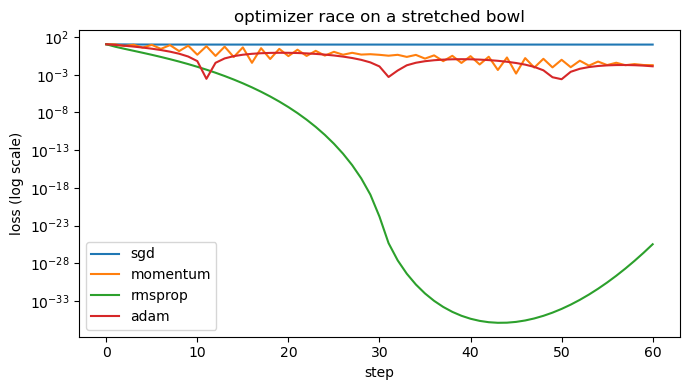

Adam (and RMSProp) plunge fastest; plain SGD lags. This is why Adam is the default.


In [5]:
import numpy as np, matplotlib.pyplot as plt
def grad(p): return np.array([2*p[0],20*p[1]])
def loss(p): return p[0]**2+10*p[1]**2
def run(opt,steps=60,lr=0.1):
    p=np.array([1.,1.]);v=s=m=np.zeros(2);hist=[loss(p)]
    v=np.zeros(2);s=np.zeros(2);m=np.zeros(2)
    for t in range(1,steps+1):
        g=grad(p)
        if opt=="sgd":p=p-lr*g
        elif opt=="momentum":v=0.9*v+g;p=p-lr*v
        elif opt=="rmsprop":s=0.9*s+0.1*g**2;p=p-lr*g/(np.sqrt(s)+1e-8)
        else:
            m=0.9*m+0.1*g;s=0.999*s+0.001*g**2;mh=m/(1-0.9**t);sh=s/(1-0.999**t);p=p-lr*mh/(np.sqrt(sh)+1e-8)
        hist.append(loss(p))
    return hist
plt.figure(figsize=(7,4))
for opt in ["sgd","momentum","rmsprop","adam"]:
    plt.semilogy(run(opt), label=opt)
plt.xlabel("step"); plt.ylabel("loss (log scale)"); plt.legend(); plt.title("optimizer race on a stretched bowl")
plt.tight_layout(); plt.show()
print("Adam (and RMSProp) plunge fastest; plain SGD lags. This is why Adam is the default.")

## B5 — Batch, minibatch, stochastic — and learning-rate schedules

Two practical questions remain about *how* the mind runs downhill. First: how much evidence does it
look at before each step — the whole library, a single page, or a handful? Second: should its stride
stay the same the whole way down? A good runner starts cautiously, opens up to full speed, then eases
off near the finish to land precisely. The mind learns to pace itself the same way.

**How much data per step?**
- **Batch GD** — use *all* data for each gradient. Accurate but slow/memory-heavy.
- **Stochastic GD** — one example per step. Noisy but fast; noise can help escape bad spots.
- **Minibatch** (the universal choice) — a small chunk (32–256). Best of both; matches hardware.

**Learning-rate schedule:** a fixed `lr` is rarely optimal — start larger to move fast, then decay
to settle precisely. Transformers typically use **warmup** (ramp up over the first steps) then
**cosine decay** (smoothly down to ~0). We plot that canonical schedule.

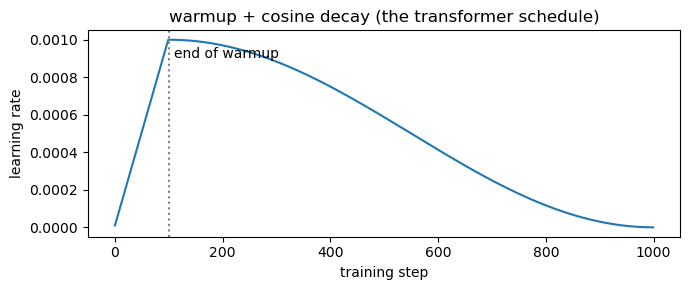

ramp up to avoid early instability, then decay to fine-tune. P09/Train_TinyGPT uses this.


In [6]:
import numpy as np, matplotlib.pyplot as plt
steps = 1000; warmup = 100; base_lr = 1e-3
lrs = []
for t in range(steps):
    if t < warmup:
        lr = base_lr * (t+1)/warmup                       # linear warmup
    else:
        prog = (t-warmup)/(steps-warmup)
        lr = base_lr * 0.5*(1+np.cos(np.pi*prog))         # cosine decay to 0
    lrs.append(lr)
plt.figure(figsize=(7,3))
plt.plot(lrs); plt.axvline(warmup, ls=":", c="gray"); plt.text(warmup+10, base_lr*0.9, "end of warmup")
plt.xlabel("training step"); plt.ylabel("learning rate"); plt.title("warmup + cosine decay (the transformer schedule)")
plt.tight_layout(); plt.show()
print("ramp up to avoid early instability, then decay to fine-tune. P09/Train_TinyGPT uses this.")

## Recap — the optimizer menu

| Optimizer | Update core | Adds |
|-----------|-------------|------|
| SGD | `w -= lr·g` | nothing (baseline) |
| Momentum | `v=βv+g; w-=lr·v` | velocity (damps zig-zag) |
| RMSProp | `w-=lr·g/√s` | per-parameter scaling |
| **Adam** | momentum **and** scaling + bias correction | the modern default |
| + schedule | warmup → cosine decay | stability then precision |

## Common mistakes
1. **Using vanilla SGD and blaming the model** when Adam would have converged. Try Adam first.
2. **Forgetting Adam's bias correction** — without it the first steps are too small.
3. **One global learning rate forever.** Schedule it (warmup + decay), especially for transformers.
4. **Batch size of 1 by accident.** Minibatches are faster and more stable; use 32–256.
5. **`ε` in the wrong place.** It guards the divide-by-zero inside the sqrt term; keep it tiny (1e-8).

## Exercises (do them in new code cells)
1. Do one Adam step by hand from `(1,1)` (t=1) and confirm against the code.
2. Race the optimizers on the *circular* bowl `x²+y²`. Does Adam still dominate, or does SGD keep up? Why?
3. Increase the stretch to `x² + 100y²`. Which optimizers still cope?
4. Change warmup to 0 in B5. How does the early learning rate differ, and why can that hurt training?
5. Set Adam's `β₁=0` (no momentum). What does Adam reduce to?

---

**The mind can now sprint downhill** — fast, balanced, and well-paced. But speed exposes a deeper
fragility: stack the brain *deep* and it starts to fall apart, signals fading to nothing or blowing up
to infinity before learning can take hold. Next we learn the tricks that hold a deep mind together:
[P13 — Making Deep Nets Train](P13_Training_Deep_Nets.ipynb) — initialization, normalization
(LayerNorm), dropout, and residual connections, each a fix for a concrete way a deep brain breaks.